## Volatility Targeting


Harvey, C. R. (with Rattray, S., & Hemert, O. van) have one section to discuss this topic in their book Strategic Risk Management: Designing Portfolios and Managing Risk. John Wiley & Sons, Incorporated.

This is heavily inspired what they implemented and tried in their book.


In short, this is to target to keep the volatility of the whole portfolio at a specific number or range instead of keep a fixed allocation in number of different assets.
For example, if your target volatility is 15%, if the current volatility is at 30%, you should sell your risky asset to lower the volatilty, vice versa. The goal is to manage the volatility to manage the risk.


Let use QQQ, BIL as an example


In [1]:
%matplotlib inline

import os
import logging

# Tell the tiportfolio default_logger to only output INFO and above
os.environ["LOG_LEVEL"] = "INFO"

logging.basicConfig(level=logging.INFO)

In [2]:
from tiportfolio.helpers.data import Alpaca
import dotenv

dotenv.load_dotenv()

import os
alpaca = Alpaca(os.environ['ALPACA_API_KEY'], os.environ['ALPACA_API_SECRET'])

In [3]:
from tiportfolio.helpers.data import YFinance
import pandas as pd
from datetime import datetime

# Initialize data sources
yf = YFinance()

# Define symbols and date range
symbols = ["QQQ", "BIL"]
start_date = "2020-01-01"
end_date = "2024-12-31"

# Fetch stock data from Alpaca
stock_data_df = alpaca.query(symbols, start_date, end_date)

# Fetch VIX data from Yahoo Finance
vix_df = yf.query(["^VIX"], start_date, end_date)
vix_series = vix_df.set_index('date')['close']

# Prepare dataframes for each strategy
qqq_prices = stock_data_df[stock_data_df['symbol'] == 'QQQ'].copy()
bil_prices = stock_data_df[stock_data_df['symbol'] == 'BIL'].copy()

# Ensure we have common dates and aligned timestamps (Midnight)
vix_series.index = pd.to_datetime(vix_series.index).tz_localize(None)
qqq_prices['date'] = pd.to_datetime(qqq_prices['date']).dt.tz_localize(None)
bil_prices['date'] = pd.to_datetime(bil_prices['date']).dt.tz_localize(None)

common_dates = set(qqq_prices['date']).intersection(set(bil_prices['date'])).intersection(set(vix_series.index))
common_dates = sorted(list(common_dates))

qqq_prices = qqq_prices[qqq_prices['date'].isin(common_dates)].set_index('date')
bil_prices = bil_prices[bil_prices['date'].isin(common_dates)].set_index('date')
vix_series = vix_series[vix_series.index.isin(common_dates)]

Loading bar data...


INFO:root:Loading:
2020-01-01 00:00:00 to 2024-12-31 00:00:00
timeframe: 1day
['BIL', 'QQQ']


Loaded bar data: 0:00:01 

Loading bar data...


INFO:root:Loading:
2020-01-01 00:00:00 to 2024-12-31 00:00:00
timeframe: 1day
['^VIX']
[*********************100%***********************]  1 of 1 completed

Loaded bar data: 0:00:02 



# Try with 90 10 on Volatility Targeting and Scheduled Rebalancing


INFO:default_logger:Initialized Allocation with 2 strategies with initial capital 100000.0. 
INFO:default_logger: - Strategy: LongHold - QQQ
INFO:default_logger: - Strategy: LongHold - BIL
INFO:default_logger:Starting walk-forward allocation process...
100%|██████████| 1257/1257 [00:00<00:00, 6678.92it/s]
INFO:default_logger:Evaluating portfolio over 1257 steps


Starting portfolio evaluation...


100%|██████████| 1257/1257 [00:02<00:00, 448.87it/s]


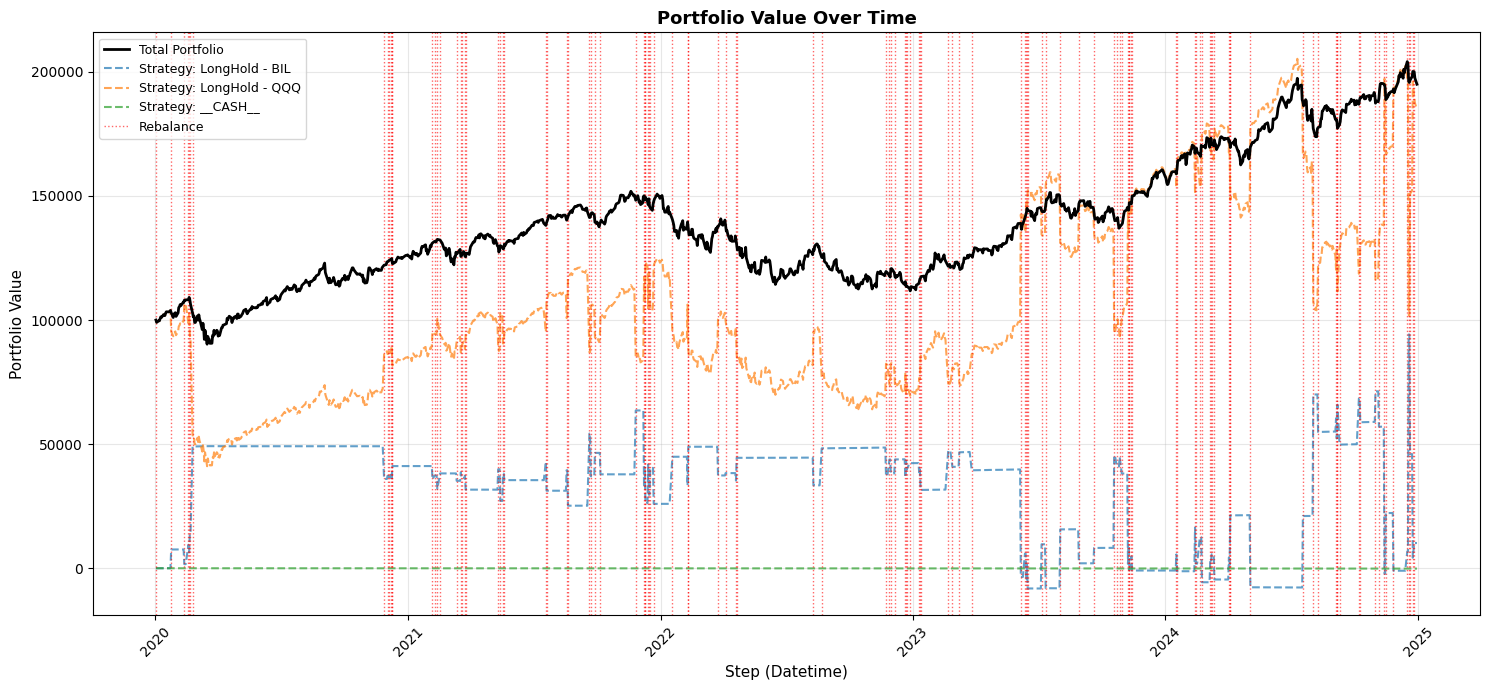

VIX Threshold Targeting Metrics:
  final_value: 195020.3775
  total_return: 0.9502
  max_drawdown: -0.2642
  sharpe_ratio: 0.7313
  annualized_return: 0.1434
  mar_ratio: 3.5972


In [4]:
from tiportfolio.strategy_library.trading.long_hold import LongHold
from tiportfolio.portfolio.allocation.vix_targeting import VixTargetingAllocation
from tiportfolio.portfolio.allocation.allocation import CASH_STRATEGY_NAME

# Create strategies
qqq_strategy = LongHold("QQQ", qqq_prices)
bil_strategy = LongHold("BIL", bil_prices)

# Configuration for the portfolio
config = {
    "initial_capital": 100000.0,
    "commission": 0.0001,  # 1bp
    "slippage": 0.0001,    # 1bp
    "risk_free_rate": 0.02,
    "market_name": "NYSE"
}

# 1. VIX Threshold-based Targeting Allocation
# We use QQQ and BIL as strategies.
# When rebalancing, risky assets scale by target_vol/VIX, remainder goes to safe assets.
vix_targeting = VixTargetingAllocation(
    config=config,
    strategies=[qqq_strategy, bil_strategy],
    vix_data=vix_series,
    base_weights={"LongHold - QQQ": 0.9, "LongHold - BIL": 0.1},
    risky_assets=["LongHold - QQQ"],
    target_vol=15.0,
    vix_boundaries=(-0.5, 6.0),
    max_leverage=1.0
)

vix_targeting.walk_forward()
vix_targeting.evaluate()
metrics_vix = vix_targeting.get_performance_metrics(plot=True, fig_size=(15, 7))
print("VIX Threshold Targeting Metrics:")
for k, v in metrics_vix.items():
    print(f"  {k}: {v:.4f}")

INFO:default_logger:Initialized Allocation with 2 strategies with initial capital 100000.0. 
INFO:default_logger: - Strategy: LongHold - QQQ
INFO:default_logger: - Strategy: LongHold - BIL
INFO:default_logger:Starting walk-forward allocation process...
100%|██████████| 1257/1257 [00:00<00:00, 6903.26it/s]
INFO:default_logger:Evaluating portfolio over 1257 steps


Starting portfolio evaluation...


100%|██████████| 1257/1257 [00:02<00:00, 436.78it/s]


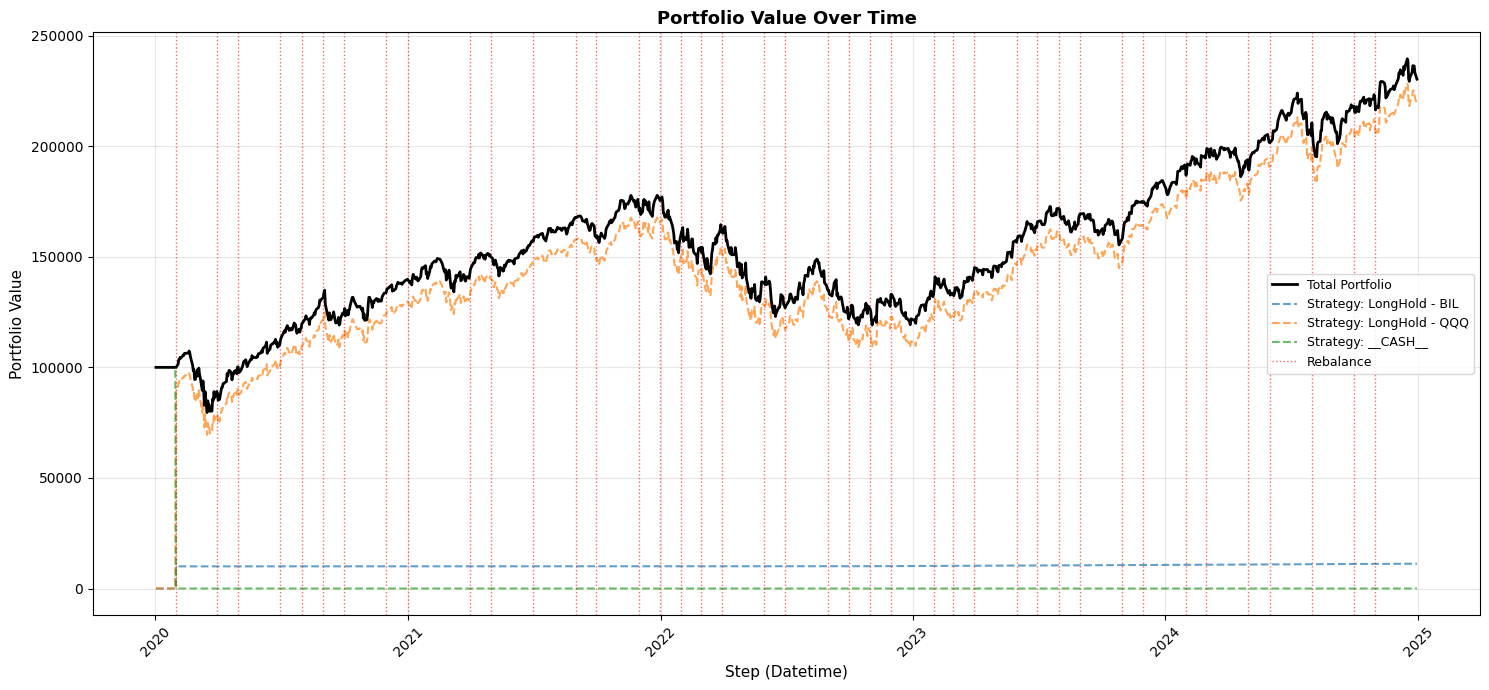

Benchmark (90/10) Metrics:
  final_value: 230299.5225
  total_return: 1.3030
  max_drawdown: -0.3299
  sharpe_ratio: 0.6900
  annualized_return: 0.1822
  mar_ratio: 3.9496


In [5]:
# Benchmark: Fixed 60/40 Allocation (Rebalanced monthly)
from tiportfolio.strategy_library.allocation.fix_ratio import FixRatioFrequencyBasedAllocation
from tiportfolio.portfolio.allocation.frequency_based_allocation import RebalanceFrequency

benchmark_allocation = FixRatioFrequencyBasedAllocation(
    config=config,
    strategies=[qqq_strategy, bil_strategy],
    allocation_ratio_list=[0.9, 0.1],
    rebalance_frequency=RebalanceFrequency.end_of_month,
    hour=0, 
    minute=0 # Align with data timestamps
)

benchmark_allocation.walk_forward()
benchmark_allocation.evaluate()
metrics_benchmark = benchmark_allocation.get_performance_metrics(plot=True, fig_size=(15, 7))
print("Benchmark (90/10) Metrics:")
for k, v in metrics_benchmark.items():
    print(f"  {k}: {v:.4f}")

In [6]:
import matplotlib.pyplot as plt

print("\nComparison Summary:")
print(f"{'Metric':<20} | {'VIX Targeting':<15} | {'Benchmark (90/10)':<15}")
print("-" * 65)
for k in metrics_vix.keys():
    print(f"{k:<20} | {metrics_vix[k]:<15.4f} | {metrics_benchmark[k]:<15.4f}")


Comparison Summary:
Metric               | VIX Targeting   | Benchmark (90/10)
-----------------------------------------------------------------
final_value          | 195020.3775     | 230299.5225    
total_return         | 0.9502          | 1.3030         
max_drawdown         | -0.2642         | -0.3299        
sharpe_ratio         | 0.7313          | 0.6900         
annualized_return    | 0.1434          | 0.1822         
mar_ratio            | 3.5972          | 3.9496         


### Summary

VIX Target 15 % voaltility is not better than schedule rebalance strategy at current settings

# On Volatility Targeting, use 15 target and 0 and 21 as boundaries

INFO:default_logger:Initialized Allocation with 2 strategies with initial capital 100000.0. 
INFO:default_logger: - Strategy: LongHold - QQQ
INFO:default_logger: - Strategy: LongHold - BIL
INFO:default_logger:Starting walk-forward allocation process...
100%|██████████| 1257/1257 [00:00<00:00, 6923.30it/s]
INFO:default_logger:Evaluating portfolio over 1257 steps


Starting portfolio evaluation...


100%|██████████| 1257/1257 [00:02<00:00, 430.28it/s]


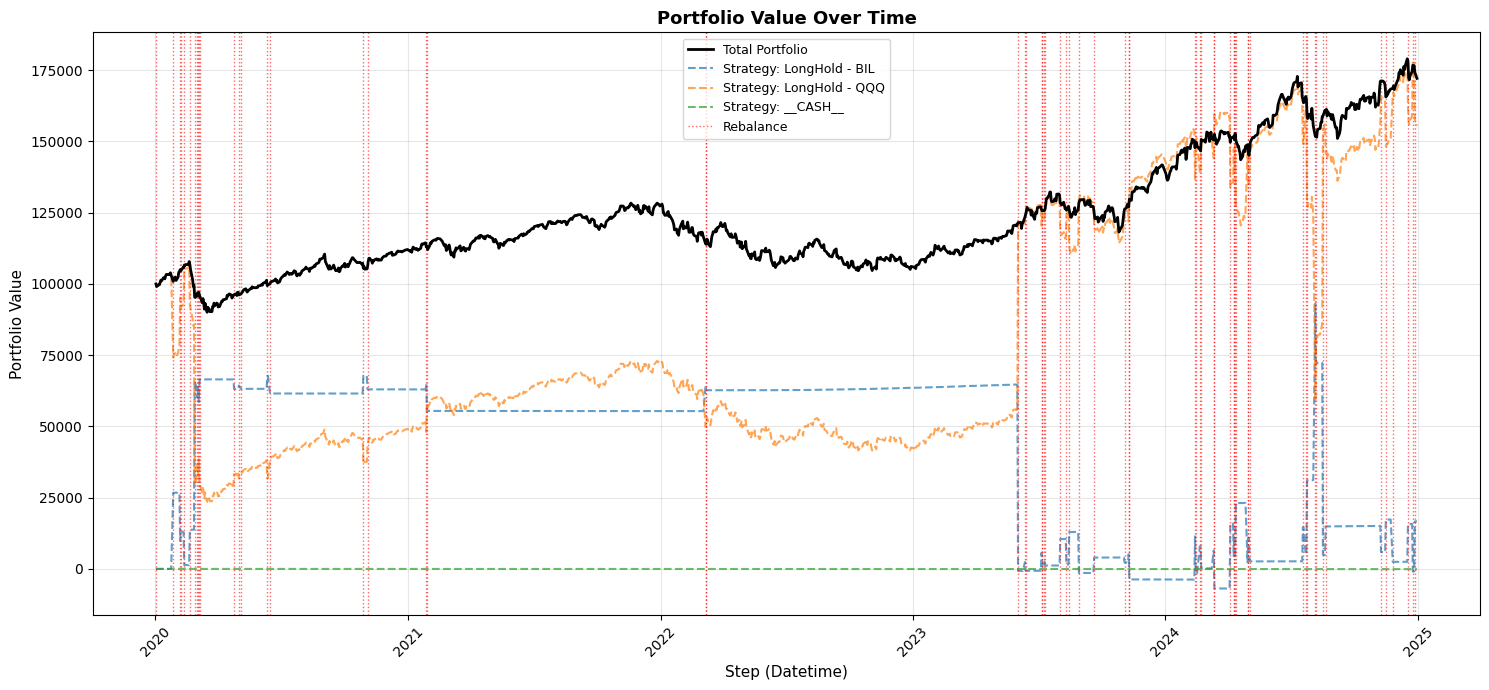

VIX Threshold Targeting Metrics:
  final_value: 172125.6072
  total_return: 0.7213
  max_drawdown: -0.1848
  sharpe_ratio: 0.6952
  annualized_return: 0.1151
  mar_ratio: 3.9029


In [7]:




# 1. VIX Threshold-based Targeting Allocation
# We use QQQ and BIL as strategies.
# When rebalancing, risky assets scale by target_vol/VIX, remainder goes to safe assets.
vix_targeting = VixTargetingAllocation(
    config=config,
    strategies=[qqq_strategy, bil_strategy],
    vix_data=vix_series,
    base_weights={"LongHold - QQQ": 0.9, "LongHold - BIL": 0.1},
    risky_assets=["LongHold - QQQ"],
    target_vol=15.0,
    vix_boundaries=(0, 21),
    max_leverage=1.0
)

vix_targeting.walk_forward()
vix_targeting.evaluate()
metrics_vix = vix_targeting.get_performance_metrics(plot=True, fig_size=(15, 7))
print("VIX Threshold Targeting Metrics:")
for k, v in metrics_vix.items():
    print(f"  {k}: {v:.4f}")

## Grid Search for Volatility Targeting Parameters

In [8]:
# Analysis of rebalance events
rebalance_dates = vix_targeting.all_rebalance_dates
print(f"Total rebalance events: {len(rebalance_dates)}")
if rebalance_dates:
    print(f"First rebalance: {rebalance_dates[0]}")
    print(f"Last rebalance: {rebalance_dates[-1]}")

# Check VIX distribution at rebalance times
vix_at_rebalance = vix_series.loc[rebalance_dates]
print("\nVIX at rebalance times:")
print(vix_at_rebalance.describe())

Total rebalance events: 64
First rebalance: 2020-01-02 00:00:00
Last rebalance: 2024-12-27 00:00:00

VIX at rebalance times:
count    64.000000
mean     21.054844
std       9.576422
min      12.470000
25%      14.840000
50%      15.605000
75%      30.654999
max      40.790001
Name: close, dtype: float64


In [9]:
import pandas as pd

# Parameter combinations to test
params_to_test = [
    {"target_vol": 15.0, "vix_boundaries": (-3.0, 10.0)},
    {"target_vol": 18.0, "vix_boundaries": (-3.0, 12.0)},
    {"target_vol": 20.0, "vix_boundaries": (-5.0, 15.0)},
    {"target_vol": 25.0, "vix_boundaries": (-5.0, 15.0)},
    {"target_vol": 15.0, "vix_boundaries": (0, 15.0)},
    {"target_vol": 15.0, "vix_boundaries": (0, 20.0)},
]

results = []
print("Running Grid Search...\n")

for p in params_to_test:
    target_vol = p["target_vol"]
    vix_boundaries = p["vix_boundaries"]
    
    # Instantiate strategy
    alloc = VixTargetingAllocation(
        config=config,
        strategies=[qqq_strategy, bil_strategy],
        vix_data=vix_series,
        base_weights={"LongHold - QQQ": 0.9, "LongHold - BIL": 0.1},
        risky_assets=["LongHold - QQQ"],
        target_vol=target_vol,
        vix_boundaries=vix_boundaries,
        max_leverage=1.0
    )
    
    # Run
    alloc.walk_forward()
    alloc.evaluate()
    metrics = alloc.get_performance_metrics(plot=False)
    
    # Get rebalance count
    rebalance_events = len(set([d for (d, s) in alloc.strategy_ratio_map.keys()]))
    
    results.append({
        "Target Vol": target_vol,
        "VIX Bounds": str(vix_boundaries),
        "Ann Return": f"{metrics.get('annualized_return', 0):.4f}",
        "Sharpe": f"{metrics.get('sharpe_ratio', 0):.4f}",
        "Max Drawdown": f"{metrics.get('max_drawdown', 0):.4f}",
        "Rebalance Events": rebalance_events
    })

# Create DataFrame
results_df = pd.DataFrame(results)

# Sort by Sharpe Ratio descending
results_df['Sharpe_float'] = results_df['Sharpe'].astype(float)
results_df = results_df.sort_values(by='Sharpe_float', ascending=False).drop(columns=['Sharpe_float'])

print("Grid Search Results (Sorted by Sharpe Ratio):")
print(results_df.to_string(index=False))


INFO:default_logger:Initialized Allocation with 2 strategies with initial capital 100000.0. 
INFO:default_logger: - Strategy: LongHold - QQQ
INFO:default_logger: - Strategy: LongHold - BIL
INFO:default_logger:Starting walk-forward allocation process...


Running Grid Search...



100%|██████████| 1257/1257 [00:00<00:00, 6512.11it/s]
INFO:default_logger:Evaluating portfolio over 1257 steps


Starting portfolio evaluation...


100%|██████████| 1257/1257 [00:02<00:00, 435.12it/s]
INFO:default_logger:Initialized Allocation with 2 strategies with initial capital 100000.0. 
INFO:default_logger: - Strategy: LongHold - QQQ
INFO:default_logger: - Strategy: LongHold - BIL
INFO:default_logger:Starting walk-forward allocation process...
100%|██████████| 1257/1257 [00:00<00:00, 7415.14it/s]
INFO:default_logger:Evaluating portfolio over 1257 steps


...

Starting portfolio evaluation...


100%|██████████| 1257/1257 [00:02<00:00, 444.41it/s]
INFO:default_logger:Initialized Allocation with 2 strategies with initial capital 100000.0. 
INFO:default_logger: - Strategy: LongHold - QQQ
INFO:default_logger: - Strategy: LongHold - BIL
INFO:default_logger:Starting walk-forward allocation process...
100%|██████████| 1257/1257 [00:00<00:00, 7158.86it/s]
INFO:default_logger:Evaluating portfolio over 1257 steps


Starting portfolio evaluation...


100%|██████████| 1257/1257 [00:02<00:00, 450.39it/s]


Grid Search Results (Sorted by Sharpe Ratio):
 Target Vol   VIX Bounds Ann Return Sharpe Max Drawdown  Rebalance Events
       15.0    (0, 20.0)     0.1172 0.6989      -0.1899                68
       20.0 (-5.0, 15.0)     0.1389 0.6958      -0.2391                68
       15.0    (0, 15.0)     0.1181 0.6865      -0.2088                90
       18.0 (-3.0, 12.0)     0.1327 0.6813      -0.2417                90
       15.0 (-3.0, 10.0)     0.1200 0.6606      -0.2293                77
       25.0 (-5.0, 15.0)     0.1609 0.5986      -0.3786                99


## Thoughts


- Need more research and trying for different parameters